This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [2]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.31.0 which is incompatible.


In [3]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [4]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## The mathematical building blocks of neural networks

### A first look at a neural network

In [5]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
train_images.shape

(60000, 28, 28)

In [7]:
len(train_labels)

60000

In [8]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [9]:
test_images.shape

(10000, 28, 28)

In [10]:
len(test_labels)

10000

In [11]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [12]:
import keras
from keras import layers
# This creates a Sequential NN model,
# which is a linear stack of layers.
# This means data will flow through each layer one after another.
model = keras.Sequential(
    [
        # first dense layer: a fully connected layer.
        # It has 512 units (neurons) and uses the Rectified Linear Unit (ReLU) activation function.
        # The ReLU function introduces non-linearity, allowing the model to learn more complex patterns.
        layers.Dense(512, activation="relu"),

        # This is the second Dense layer, which serves as the output layer.
        # It has 10 units, corresponding to the 10 possible digits (0-9) in the MNIST dataset.
        # The softmax activation function ensures that the output is a probability distribution over these 10 classes, meaning the sum of the outputs for all 10 units will be 1.
        layers.Dense(10, activation="softmax"),
    ]
)

In [13]:
# Prepares the model for training
model.compile(
    # Adaptive Moment Estimation(ADAM):
      # optimization algorithm that adjusts the model's weights during training to minimize the loss.
    optimizer="adam",

    # measures how well the model is performing.
    # by calculating the difference between the model's predicted probability distribution and the true label.
    loss="sparse_categorical_crossentropy",

    #  metrics like 'accuracy' provide a human-readable measure of performance, indicating the proportion of correctly classified samples.
    metrics=["accuracy"],
)

In [14]:
# Preprocessing steps
# Neural networks perform better when input values are scaled down to a smaller, standardized range (e.g., 0 to 1).

# 1. Reshaping the images from 2-D array(28*28 pixels) --> 1-D vector(784 pixels)
train_images = train_images.reshape((60000, 28 * 28))

# 2. Normalizing pixel values
#   convert the pixel data type to floating-point numbers and
#   then divide every pixel value by 255.
#   This effectively scales all pixel values to be between 0.0 and 1.0.
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

The values for **epochs and batch_size** are *hyper-parameters* that are often chosen based on experimentation and best practices. Here's what they mean and why these specific values might be used:

Epochs (5 in this case):

An epoch is one complete pass through the entire training dataset. In each epoch, the model sees every training example once and updates its weights.
Choosing epochs=5 means the model will iterate over the entire training dataset five times. For simple datasets like MNIST, a small number of epochs is often sufficient for the model to learn the patterns. Too few epochs might lead to underfitting (the model hasn't learned enough), while too many can lead to overfitting (the model memorizes the training data and performs poorly on new data). This value is typically tuned.
Batch Size (128 in this case):

The batch size determines the number of samples that will be propagated through the network at once. The model's weights are updated after each batch.
Choosing batch_size=128 is a common practice. Smaller batch sizes (e.g., 32, 64) can lead to more noisy but potentially better generalization, while larger batch sizes (e.g., 256, 512) can provide a more stable gradient estimate and faster training per epoch, but might get stuck in local minima. A batch size of 128 is a good balance between these trade-offs and often works well for many tasks.

What do you mean by this: Smaller batch sizes (e.g., 32, 64) can lead to more noisy but potentially better generalization
When we talk about "noisy" with smaller batch sizes, it refers to the fact that the gradient (the direction and magnitude of the update to the model's weights) calculated from a small batch of data is less representative of the true gradient of the entire dataset. This makes the optimization path more erratic or 'noisy'.

However, this 'noise' can actually be beneficial for "better generalization":

Escape from Local Minima: The noisy updates from smaller batches can help the model escape shallow local minima in the loss landscape. If the model were to consistently update based on very stable gradients from large batches, it might get stuck in a suboptimal solution. The stochastic (random) nature of smaller batches can 'kick' the model out of these traps.
Regularization Effect: The fluctuating updates act as a form of regularization. They prevent the model from becoming too confident or over-specializing in the training data patterns. This can lead to a more robust model that performs better on unseen data.
Wider Basins: Some research suggests that smaller batch sizes tend to converge to flatter minima in the loss landscape, which are generally associated with better generalization to new, unseen data.
In essence, while larger batch sizes provide a more stable and accurate estimate of the gradient, the inherent instability and randomness introduced by smaller batches can surprisingly help the model learn more generalizable features and avoid overfitting.



In [16]:
# Training you NN model
# Two quantities are displayed during training:
  # the loss of the model over the training data
  # the accuracy of the model over the training data
# function to train a model;
# takes the training data and labels and
  # iteratively adjusts the model's internal parameters(weight and biases) to minimize the loss function and improve accuracy.
model.fit(
    train_images, # input images that the model will learn from
    train_labels, # labels for the train_images that the model uses to compare its predictions and calculate the loss

    epochs=5, # number fo complete passes through the entire dataset
    batch_size=128) # the model processes data in small batches to bring efficiency and stability

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9928 - loss: 0.0265
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9950 - loss: 0.0204
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9955 - loss: 0.0162
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9963 - loss: 0.0133
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9978 - loss: 0.0098


In [18]:
# From this trained model,
  # we can use it to predict class probabilities for new digits—images that weren’t part of the training data, like those from the test set.
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([1.40894307e-09, 1.11287014e-10, 1.15088892e-06, 9.53314666e-05,
       1.09265270e-11, 1.25688626e-09, 2.17304690e-13, 9.99899387e-01,
       1.33569699e-07, 4.04085813e-06], dtype=float32)

In [24]:
# determine the digit (0-9) that the model predicts for the first test image.
# The predictions[0] array contains the probability distribution for each of the 10 digits.
# The argmax() method then returns the index of the element in this array that has the highest probability, which represents the model's most confident prediction.
predictions[0].argmax()

np.int64(7)

In [20]:
predictions[0][7]

np.float32(0.9998994)

In [21]:
test_labels[0]

np.uint8(7)

In [29]:
# On average, how good is our model at classifying such never-before-seen digits?
# Let’s check by computing average accuracy over the entire test set.
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")
# The test set accuracy turns out to be 97.8%—that’s almost double the error rate of the training set (at 98.9% accuracy). This gap between training accuracy and test accuracy is an example of overfitting: the fact that machine learning models tend to perform worse on new data than on their training data.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9807 - loss: 0.0648
test_acc: 0.9807000160217285


### Visualizing Training Progress

To see how the model's accuracy and loss evolve during training, we need to capture the `History` object returned by `model.fit()`. We'll re-initialize the model to start training from scratch and then plot the results.

In [26]:
import keras
from keras import layers

# Re-initialize the model to train from scratch
model_for_plotting = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

# Re-compile the model
model_for_plotting.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [27]:
# Re-run the training and capture the history object
history = model_for_plotting.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9237 - loss: 0.2705
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9680 - loss: 0.1108
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9784 - loss: 0.0720
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9850 - loss: 0.0518
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9884 - loss: 0.0380


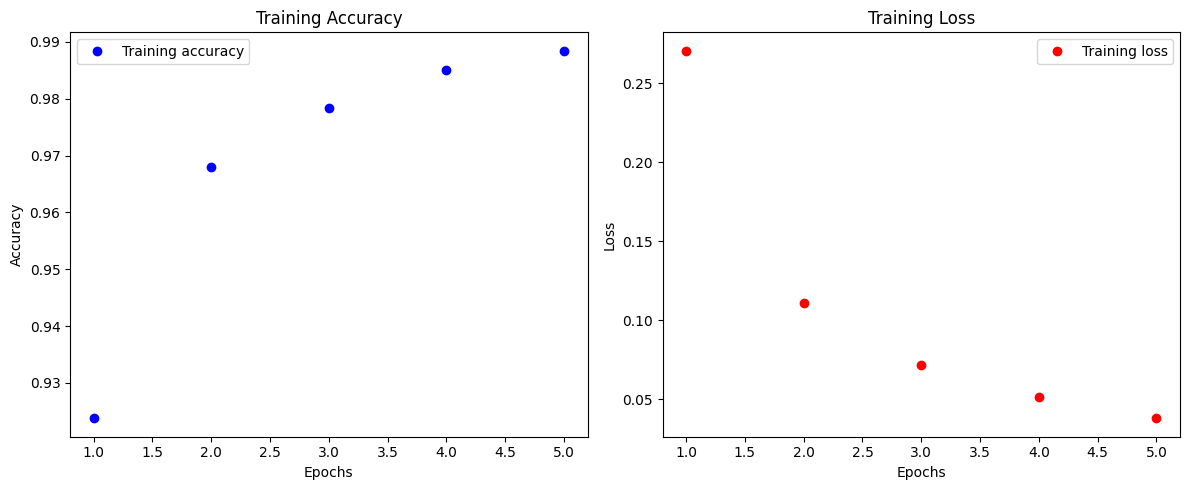

In [28]:
import matplotlib.pyplot as plt

# Get the accuracy and loss values from the history object
accuracy = history.history['accuracy']
loss = history.history['loss']
epochs = range(1, len(accuracy) + 1)

# Plotting training accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting training loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, loss, 'ro', label='Training loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Data representations for neural networks

#### Scalars (rank-0 tensors)

In [ ]:
import numpy as np
x = np.array(12)
x

In [ ]:
x.ndim

#### Vectors (rank-1 tensors)

In [ ]:
x = np.array([12, 3, 6, 14, 7])
x

In [ ]:
x.ndim

#### Matrices (rank-2 tensors)

In [ ]:
x = np.array([[5, 78, 2, 34, 0],
              [6, 79, 3, 35, 1],
              [7, 80, 4, 36, 2]])
x.ndim

#### Rank-3 tensors and higher-rank tensors

In [ ]:
x = np.array([[[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]]])
x.ndim

#### Key attributes

In [ ]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [ ]:
train_images.ndim

In [ ]:
train_images.shape

In [ ]:
train_images.dtype

In [ ]:
import matplotlib.pyplot as plt

digit = train_images[4]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

In [ ]:
train_labels[4]

#### Manipulating tensors in NumPy

In [ ]:
my_slice = train_images[10:100]
my_slice.shape

In [ ]:
my_slice = train_images[10:100, :, :]
my_slice.shape

In [ ]:
my_slice = train_images[10:100, 0:28, 0:28]
my_slice.shape

In [ ]:
my_slice = train_images[:, 14:, 14:]

In [ ]:
my_slice = train_images[:, 7:-7, 7:-7]

#### The notion of data batches

In [ ]:
batch = train_images[:128]

In [ ]:
batch = train_images[128:256]

In [ ]:
n = 3
batch = train_images[128 * n : 128 * (n + 1)]

#### Real-world examples of data tensors

##### Vector data

##### Timeseries data or sequence data

##### Image data

##### Video data

### The gears of neural networks: Tensor operations

#### Element-wise operations

In [ ]:
def naive_relu(x):
    assert len(x.shape) == 2
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] = max(x[i, j], 0)
    return x

In [ ]:
def naive_add(x, y):
    assert len(x.shape) == 2
    assert x.shape == y.shape
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[i, j]
    return x

In [ ]:
import time

x = np.random.random((20, 100))
y = np.random.random((20, 100))

t0 = time.time()
for _ in range(1000):
    z = x + y
    z = np.maximum(z, 0.0)
print("Took: {0:.2f} s".format(time.time() - t0))

In [ ]:
t0 = time.time()
for _ in range(1000):
    z = naive_add(x, y)
    z = naive_relu(z)
print("Took: {0:.2f} s".format(time.time() - t0))

#### Broadcasting

In [ ]:
import numpy as np

X = np.random.random((32, 10))
y = np.random.random((10,))

In [ ]:
y = np.expand_dims(y, axis=0)

In [ ]:
Y = np.tile(y, (32, 1))

In [ ]:
def naive_add_matrix_and_vector(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[j]
    return x

In [ ]:
import numpy as np

x = np.random.random((64, 3, 32, 10))
y = np.random.random((32, 10))
z = np.maximum(x, y)

#### Tensor product

In [ ]:
x = np.random.random((32,))
y = np.random.random((32,))

z = np.matmul(x, y)
z = x @ y

In [ ]:
def naive_vector_product(x, y):
    assert len(x.shape) == 1
    assert len(y.shape) == 1
    assert x.shape[0] == y.shape[0]
    z = 0.0
    for i in range(x.shape[0]):
        z += x[i] * y[i]
    return z

In [ ]:
def naive_matrix_vector_product(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            z[i] += x[i, j] * y[j]
    return z

In [ ]:
def naive_matrix_vector_product(x, y):
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        z[i] = naive_vector_product(x[i, :], y)
    return z

In [ ]:
def naive_matrix_product(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 2
    assert x.shape[1] == y.shape[0]
    z = np.zeros((x.shape[0], y.shape[1]))
    for i in range(x.shape[0]):
        for j in range(y.shape[1]):
            row_x = x[i, :]
            column_y = y[:, j]
            z[i, j] = naive_vector_product(row_x, column_y)
    return z

#### Tensor reshaping

In [ ]:
train_images = train_images.reshape((60000, 28 * 28))

In [ ]:
x = np.array([[0., 1.],
              [2., 3.],
              [4., 5.]])
x.shape

In [ ]:
x = x.reshape((6, 1))
x

In [ ]:
x = x.reshape((2, 3))
x

In [ ]:
x = np.zeros((300, 20))
x = np.transpose(x)
x.shape

#### Geometric interpretation of tensor operations

#### A geometric interpretation of deep learning

### The engine of neural networks: Gradient-based optimization

#### What's a derivative?

#### Derivative of a tensor operation: The gradient

#### Stochastic gradient descent

#### Chaining derivatives: The Backpropagation algorithm

##### The chain rule

##### Automatic differentiation with computation graphs

### Looking back at our first example

In [ ]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
model.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128,
)

#### Reimplementing our first example from scratch

##### A simple Dense class

In [ ]:
import keras
from keras import ops

class NaiveDense:
    def __init__(self, input_size, output_size, activation=None):
        self.activation = activation
        self.W = keras.Variable(
            shape=(input_size, output_size), initializer="uniform"
        )
        self.b = keras.Variable(shape=(output_size,), initializer="zeros")

    def __call__(self, inputs):
        x = ops.matmul(inputs, self.W)
        x = x + self.b
        if self.activation is not None:
            x = self.activation(x)
        return x

    @property
    def weights(self):
        return [self.W, self.b]

##### A simple Sequential class

In [ ]:
class NaiveSequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, inputs):
        x = inputs
        for layer in self.layers:
            x = layer(x)
        return x

    @property
    def weights(self):
        weights = []
        for layer in self.layers:
            weights += layer.weights
        return weights

In [ ]:
model = NaiveSequential(
    [
        NaiveDense(input_size=28 * 28, output_size=512, activation=ops.relu),
        NaiveDense(input_size=512, output_size=10, activation=ops.softmax),
    ]
)
assert len(model.weights) == 4

##### A batch generator

In [ ]:
import math

class BatchGenerator:
    def __init__(self, images, labels, batch_size=128):
        assert len(images) == len(labels)
        self.index = 0
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.num_batches = math.ceil(len(images) / batch_size)

    def next(self):
        images = self.images[self.index : self.index + self.batch_size]
        labels = self.labels[self.index : self.index + self.batch_size]
        self.index += self.batch_size
        return images, labels

#### Running one training step

##### The weight update step

In [ ]:
learning_rate = 1e-3

def update_weights(gradients, weights):
    for g, w in zip(gradients, weights):
        w.assign(w - g * learning_rate)

In [ ]:
from keras import optimizers

optimizer = optimizers.SGD(learning_rate=1e-3)

def update_weights(gradients, weights):
    optimizer.apply_gradients(zip(gradients, weights))

##### Gradient computation

In [ ]:
%%backend tensorflow
import tensorflow as tf

x = tf.zeros(shape=())
with tf.GradientTape() as tape:
    y = 2 * x + 3
grad_of_y_wrt_x = tape.gradient(y, x)

In [ ]:
%%backend tensorflow
def one_training_step(model, images_batch, labels_batch):
    with tf.GradientTape() as tape:
        predictions = model(images_batch)
        loss = ops.sparse_categorical_crossentropy(labels_batch, predictions)
        average_loss = ops.mean(loss)
    gradients = tape.gradient(average_loss, model.weights)
    update_weights(gradients, model.weights)
    return average_loss

#### The full training loop

In [ ]:
%%backend tensorflow
def fit(model, images, labels, epochs, batch_size=128):
    for epoch_counter in range(epochs):
        print(f"Epoch {epoch_counter}")
        batch_generator = BatchGenerator(images, labels)
        for batch_counter in range(batch_generator.num_batches):
            images_batch, labels_batch = batch_generator.next()
            loss = one_training_step(model, images_batch, labels_batch)
            if batch_counter % 100 == 0:
                print(f"loss at batch {batch_counter}: {loss:.2f}")

In [ ]:
%%backend tensorflow
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

fit(model, train_images, train_labels, epochs=10, batch_size=128)

#### Evaluating the model

In [ ]:
%%backend tensorflow
predictions = model(test_images)
predicted_labels = ops.argmax(predictions, axis=1)
matches = predicted_labels == test_labels
f"accuracy: {ops.mean(matches):.2f}"